In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

Processing LR: 1e-2...
  Saved plot to save/figures/linear_gaussian_w2diff_1e-2.pdf


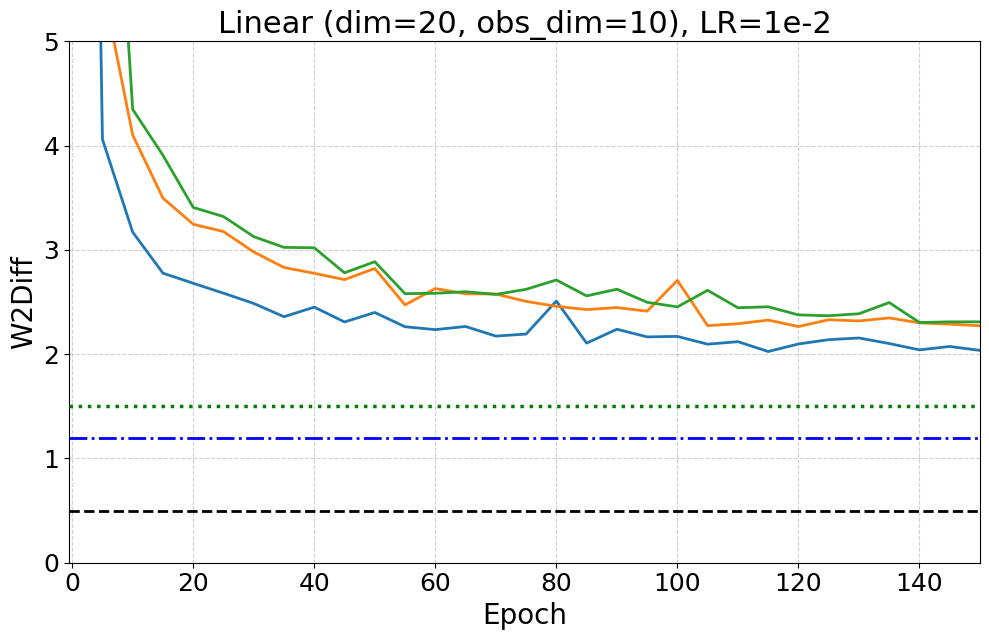

Processing LR: 5e-3...
  Saved plot to save/figures/linear_gaussian_w2diff_5e-3.pdf


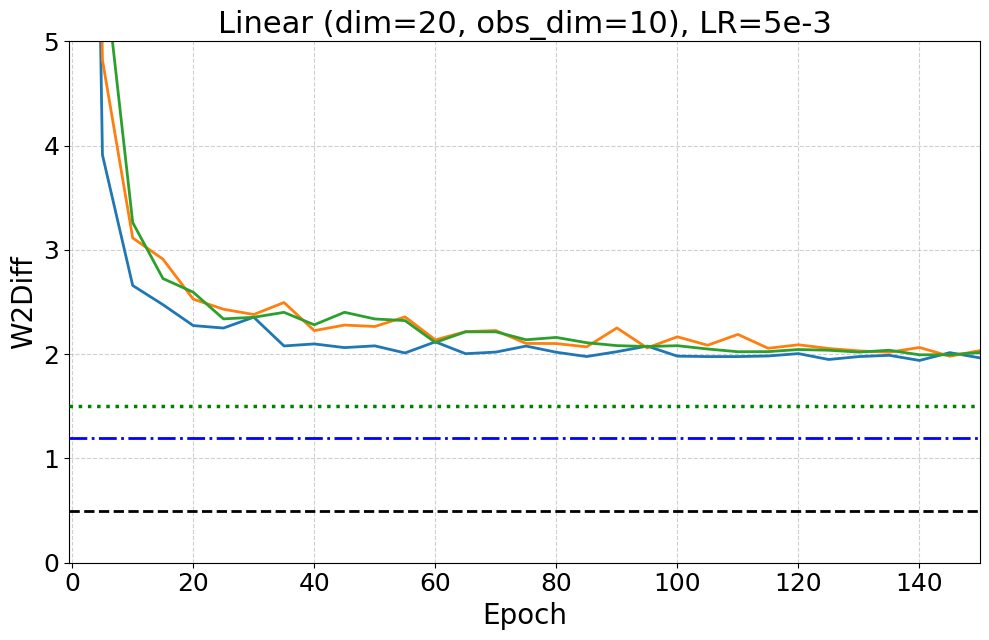

Processing LR: 1e-3...
  Saved plot to save/figures/linear_gaussian_w2diff_1e-3.pdf


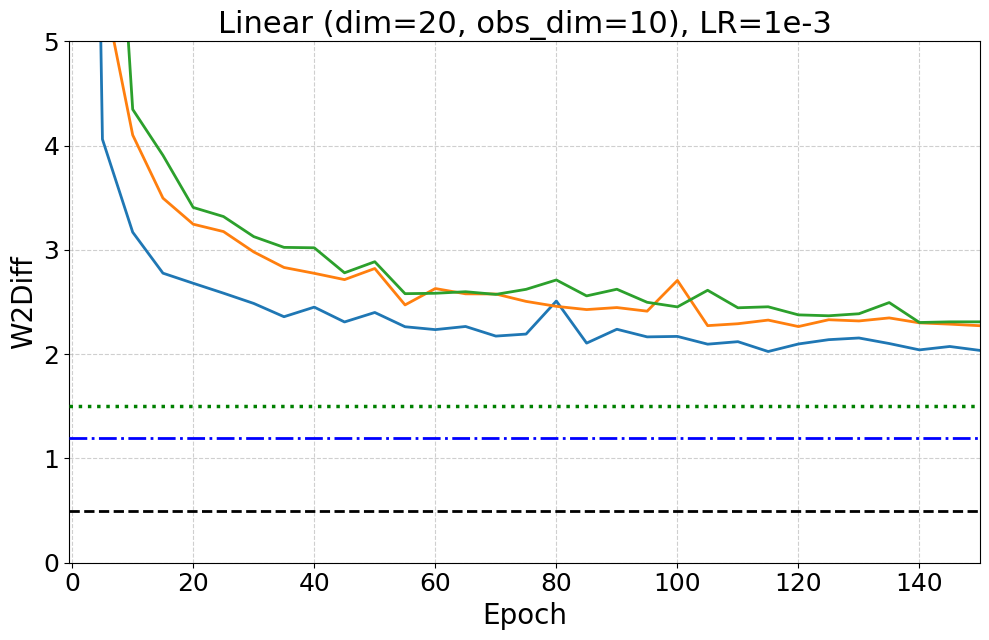

Processing LR: 5e-4...
  Saved plot to save/figures/linear_gaussian_w2diff_5e-4.pdf


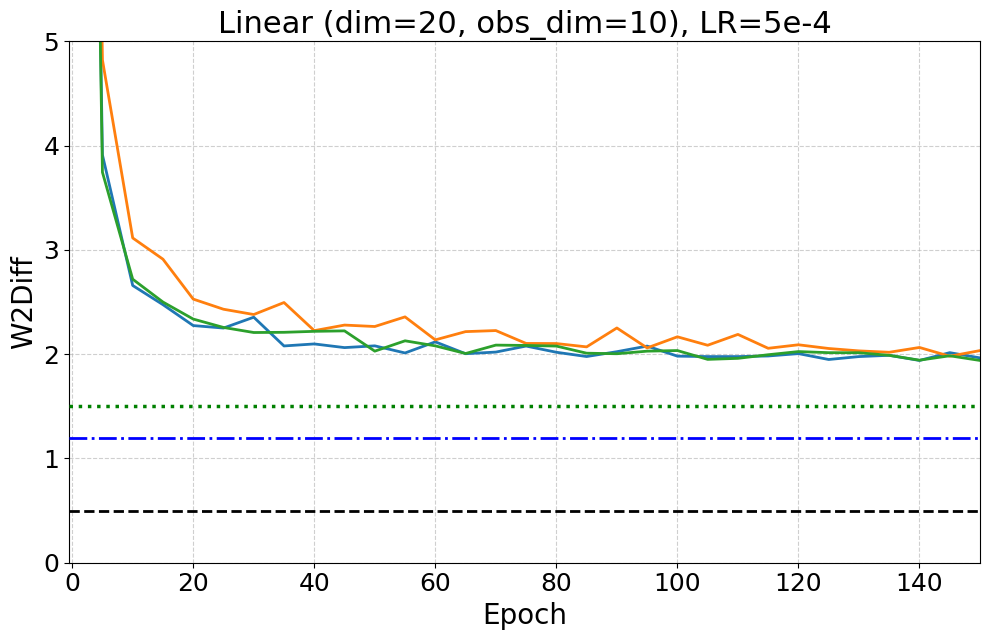

Saved corrected legend to save/figures/linear_gaussian_w2diff_legend.pdf


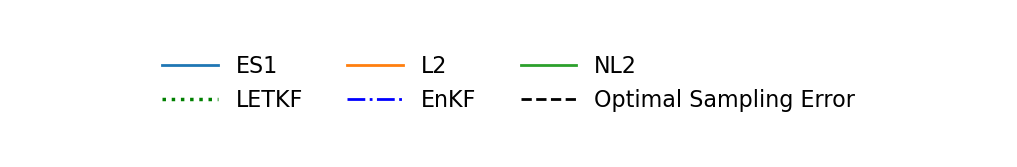

In [ ]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================
FIGSIZE_MAIN = (10, 6.5)
FIGSIZE_LEGEND = (10, 1.5) # Adjusted height

# Line Styles
MAIN_LINE_WIDTH = 2.0
GT_COLOR, GT_LS, GT_LW, GT_LABEL = "k", "--", 2.0, "Optimal Sampling Error"
ENKF_COLOR, ENKF_LS, ENKF_LW, ENKF_LABEL = "blue", "-.", 2.0, "EnKF"
LETKF_COLOR, LETKF_LS, LETKF_LW, LETKF_LABEL = "green", ":", 2.5, "LETKF"

# Axes & Grid
X_LIM = (-0.5, 150) # CHANGED: Limit to 150 epochs
Y_LIM = (0, 5)
GRID_LS = "--"
GRID_ALPHA = 0.6

# Font sizes
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 16 # Slightly larger for readability

# =================== Data Setup ===================
gt_mean, enkf_mean, letkf_mean = 0.5, 1.2, 1.5

# 2. Define LR configurations
lr_folder_map = {
    "1e-2": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-2'
    ],
    "5e-3": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_5e-3'
    ],
    "1e-3": [
        '2026-01-04_19-49linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-3'
    ],
    "5e-4": [
        '2026-01-04_19-47linear_1_10_60_8192_es_joint_EtE-LRes_20_5e-4',
        '2026-01-04_19-47linear_1_10_60_8192_l2_joint_EtE-LRes_20_5e-4',
        '2026-01-04_19-49linear_1_10_60_8192_nes_joint_EtE-LRes_20_5e-4'
    ]
}

method_names = ['ES1', 'L2', 'NL2']
lrs_to_plot = ["1e-2", "5e-3", "1e-3", "5e-4"]
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Main Loop ===================

for lr in lrs_to_plot:
    print(f"Processing LR: {lr}...")
    folder_names = lr_folder_map.get(lr, [])
    
    # Init Figure
    fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
    
    # CHANGED: Added detailed title
    title_str = f"Linear (dim=20, obs_dim=10), LR={lr}"
    ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

    # 1. Plot Methods
    for i, folder_name in enumerate(folder_names):
        file_path = os.path.join('save', 'linear_gaussian_example', folder_name, 'training_records.pt')
        
        if os.path.exists(file_path):
            data = torch.load(file_path, weights_only=True)
            mean_curve = np.array(data.get('mean_w2_diff', []))
            epochs = np.array(data.get('test_epochs', []))
            
            if len(mean_curve) > 0:
                ax.plot(epochs, mean_curve, linewidth=MAIN_LINE_WIDTH, label=method_names[i])
        else:
            print(f"  Missing: {folder_name}")

    # 2. Plot Baselines (Horizontal lines)
    ax.axhline(y=gt_mean, color=GT_COLOR, ls=GT_LS, lw=GT_LW, label=GT_LABEL, zorder=10)
    ax.axhline(y=enkf_mean, color=ENKF_COLOR, ls=ENKF_LS, lw=ENKF_LW, label=ENKF_LABEL, zorder=10)
    ax.axhline(y=letkf_mean, color=LETKF_COLOR, ls=LETKF_LS, lw=LETKF_LW, label=LETKF_LABEL, zorder=10)

    # 3. Formatting
    ax.set_ylabel('W2Diff', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
    ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
    ax.set_xlim(*X_LIM) # CHANGED limit
    ax.set_ylim(*Y_LIM)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    
    # Save Main Plot
    save_path = os.path.join(out_dir, f"linear_gaussian_w2diff_{lr}.pdf")
    fig.tight_layout()
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"  Saved plot to {save_path}")
    
    plt.show(fig) 

# =================== Legend Generation (Shared) ===================

# CHANGED: Explicitly define the visual order
# Row 1: ES1, L2, NL2
# Row 2: LETKF, EnKF, Optimal Sampling Error
desired_order_visual = [
    'ES1', 'L2', 'NL2', 
    LETKF_LABEL, ENKF_LABEL, GT_LABEL
]

# Get handles from the last ax instance
handles, labels = ax.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

# Reorder handles strictly based on the visual list
ordered_handles = []
ordered_labels = []
for lab in desired_order_visual:
    if lab in label_to_handle:
        ordered_handles.append(label_to_handle[lab])
        ordered_labels.append(lab)
    else:
        print(f"Warning: Label '{lab}' not found in plot handles.")

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')

# ncol=3 means it fills Row 1 (Item 1,2,3) then Row 2 (Item 4,5,6)
ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=3, 
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.5,
    columnspacing=2.0, # Increased spacing for better separation
    labelspacing=1.0
)

legend_path = os.path.join(out_dir, "linear_gaussian_w2diff_legend.pdf")
fig_legend.tight_layout(pad=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight")
print(f"Saved corrected legend to {legend_path}")

plt.show(fig_legend)

--- Processing Metric: mean_cov_diff ---
  Processing LR: 1e-2...
    Saved plot to save/figures/lorenz63_rcov_diff_1e-2.pdf


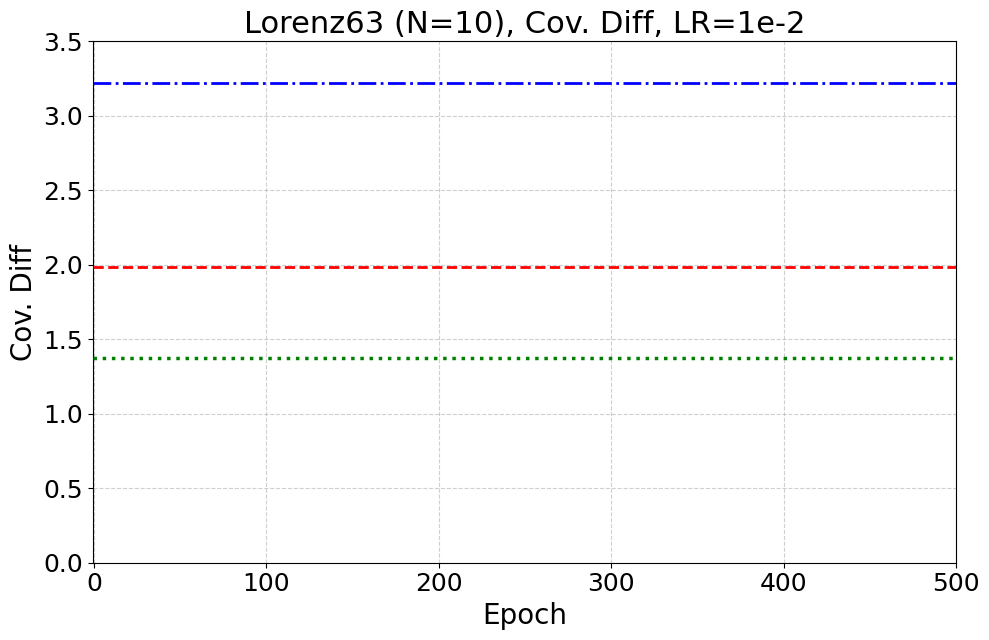

  Processing LR: 5e-3...
    Saved plot to save/figures/lorenz63_rcov_diff_5e-3.pdf


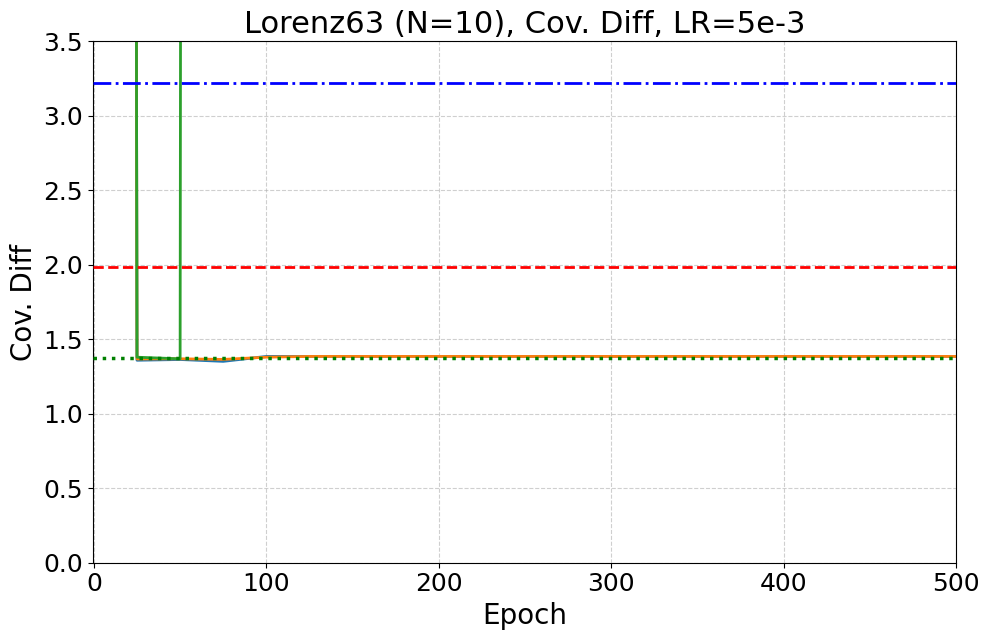

  Processing LR: 1e-3...
    Saved plot to save/figures/lorenz63_rcov_diff_1e-3.pdf


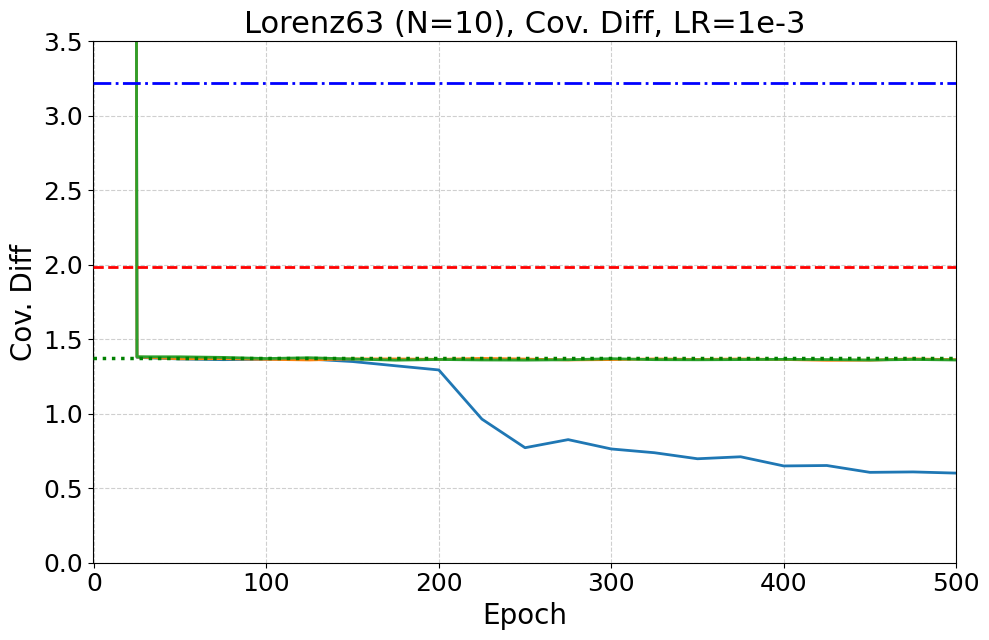

  Processing LR: 5e-4...
    Saved plot to save/figures/lorenz63_rcov_diff_5e-4.pdf


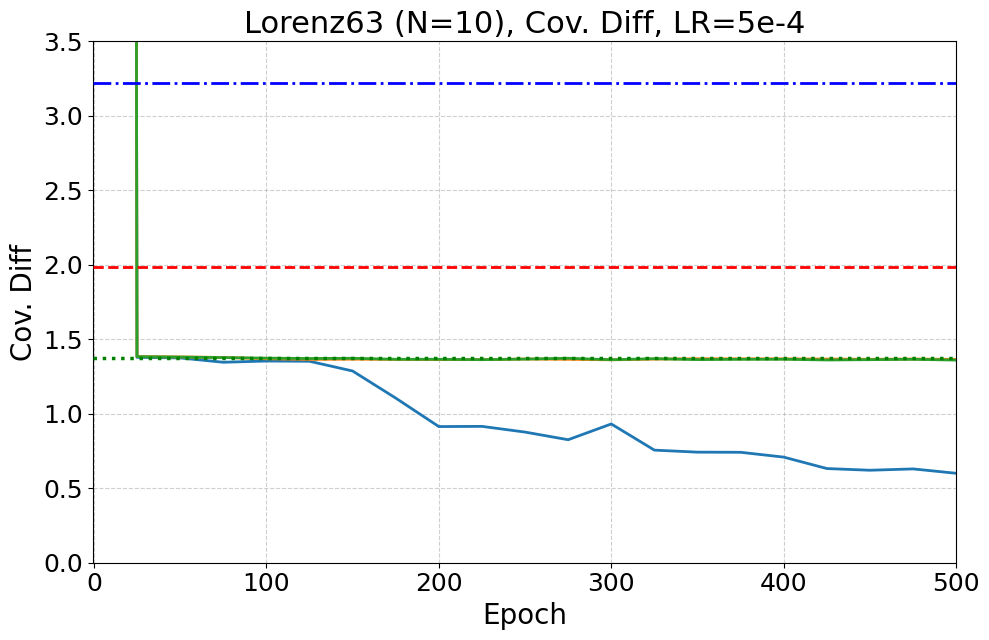

--- Processing Metric: mean_pf_rrmse ---
  Processing LR: 1e-2...
    Saved plot to save/figures/lorenz63_pf_rrmse_1e-2.pdf


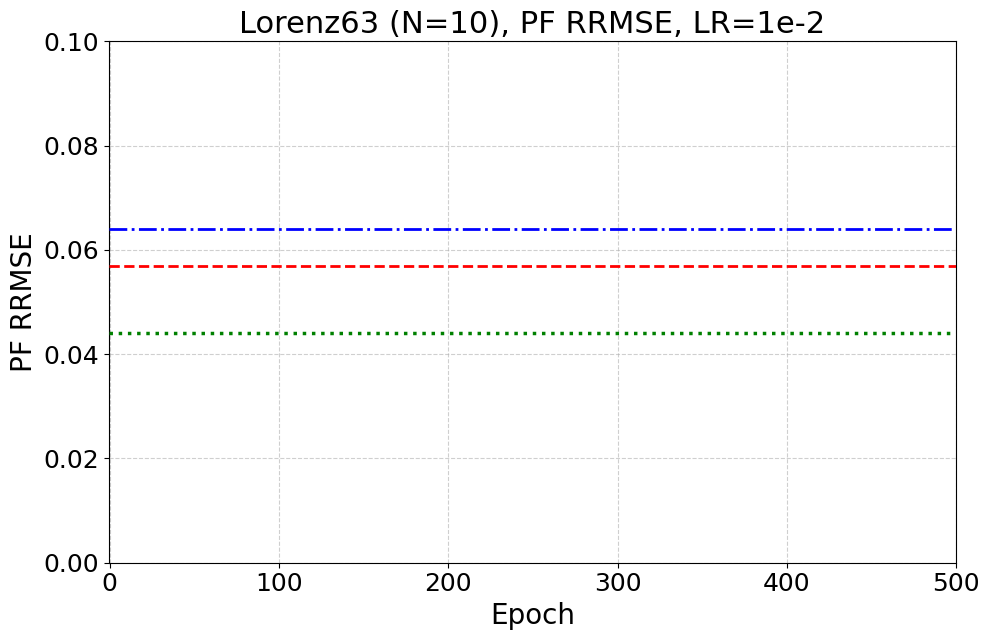

  Processing LR: 5e-3...
    Saved plot to save/figures/lorenz63_pf_rrmse_5e-3.pdf


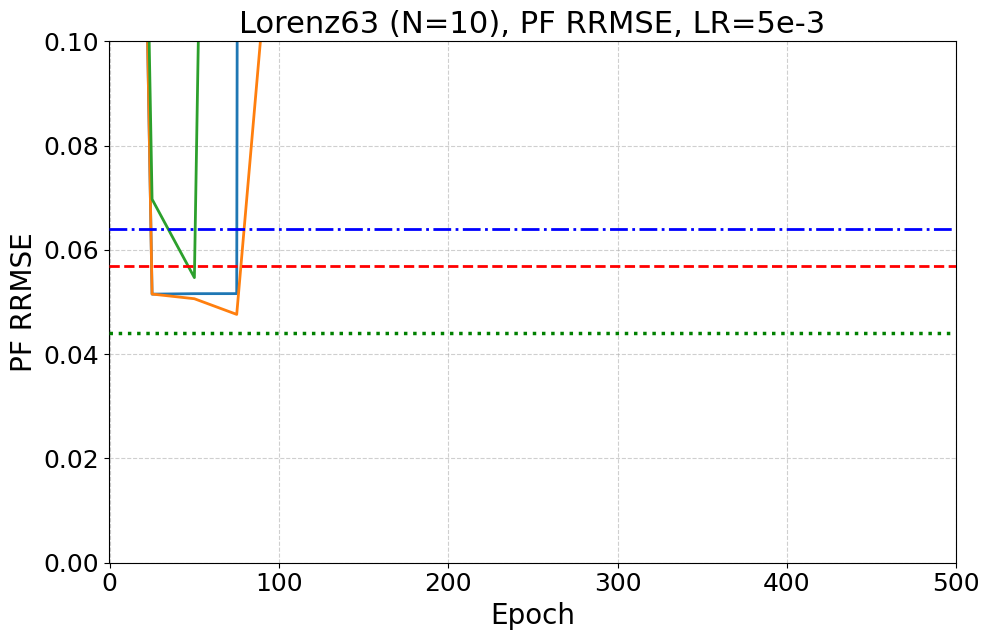

  Processing LR: 1e-3...
    Saved plot to save/figures/lorenz63_pf_rrmse_1e-3.pdf


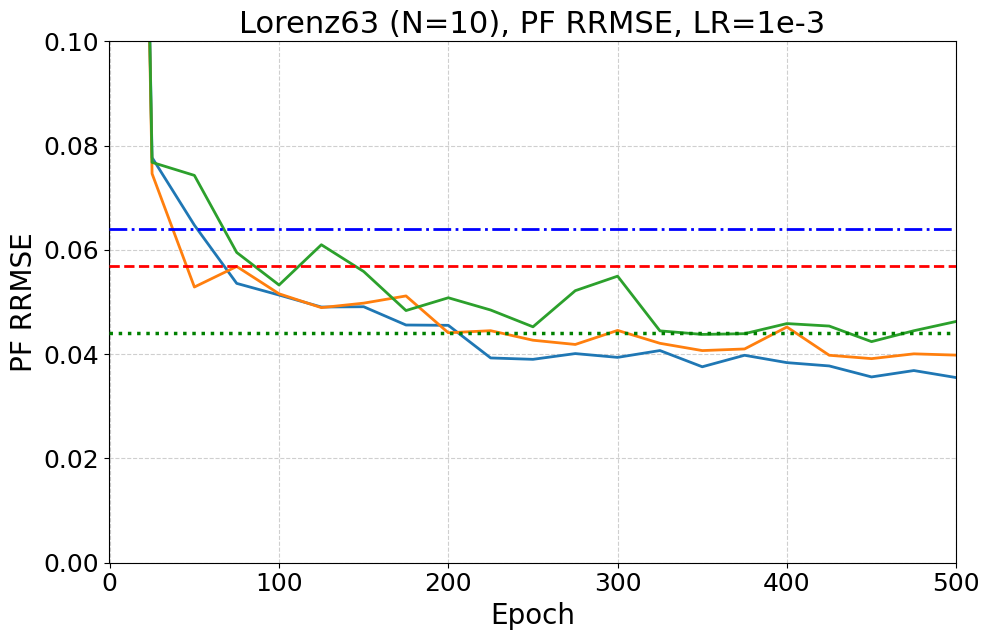

  Processing LR: 5e-4...
    Saved plot to save/figures/lorenz63_pf_rrmse_5e-4.pdf


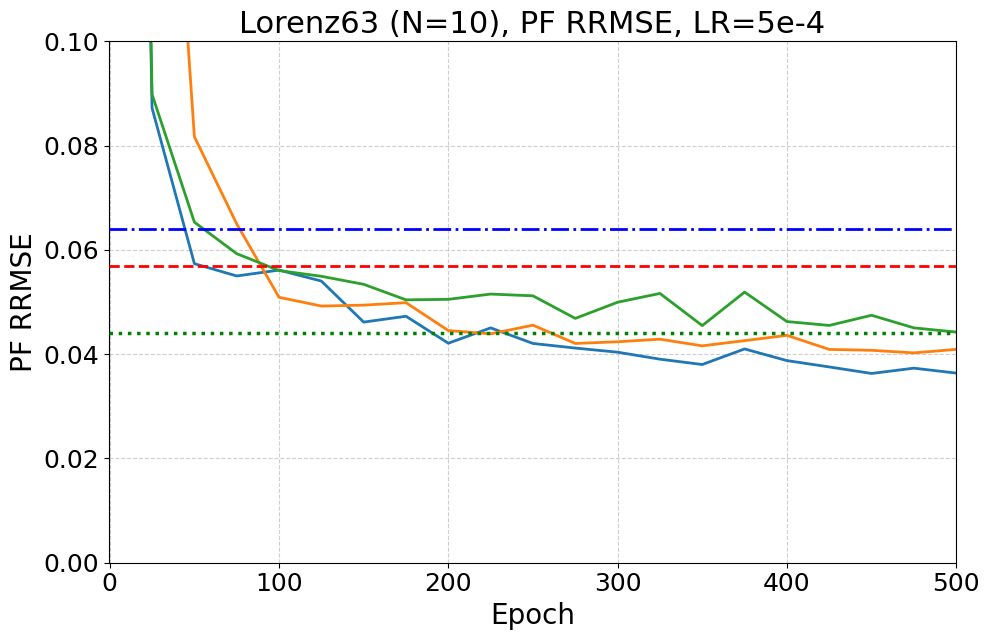

Saved corrected legend to save/figures/lorenz63_legend.pdf


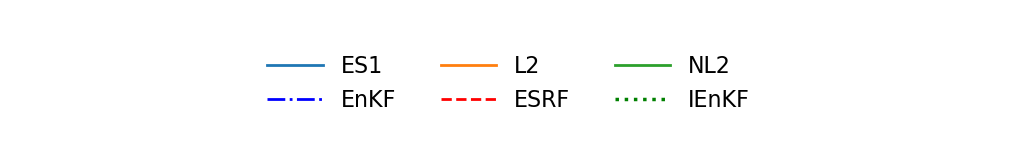

In [26]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================
FIGSIZE_MAIN = (10, 6.5)
FIGSIZE_LEGEND = (10, 1.5)

# Line Styles
MAIN_LINE_WIDTH = 2.0

# Axes & Grid
X_LIM = (-0.5, 500) 
GRID_LS = "--"
GRID_ALPHA = 0.6

# Font sizes
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 16 

# =================== Data Configuration ===================

# 1. Benchmark Data
benchmark_data = {
    "EnKF": {
        "mean_cov_diff": 3.218,
        "mean_pf_rrmse": 0.064
    },
    "ESRF": {
        "mean_cov_diff": 1.984,
        "mean_pf_rrmse": 0.057
    },
    "IEnKF": {
        "mean_cov_diff": 1.372,
        "mean_pf_rrmse": 0.044
    }
}

# 2. Define Styles for Benchmarks (UPDATED FOR COLORS)
benchmark_styles = {
    "EnKF":  {"color": "blue",   "linestyle": "-.", "linewidth": 2.0},
    "ESRF":  {"color": "red",    "linestyle": "--", "linewidth": 2.0}, # Red dashed
    "IEnKF": {"color": "green",  "linestyle": ":",  "linewidth": 2.5}, # Green dotted
    # Default fallback
    "default": {"color": "k", "linestyle": "--", "linewidth": 2.0} 
}

# 3. Define Metrics to plot
metrics_config = [
    {
        "key": 'mean_cov_diff',
        "ylabel": "Cov. Diff",
        "fname": "rcov_diff",
        "ylim": (0, 3.5) 
    },
    {
        "key": 'mean_pf_rrmse',
        "ylabel": "PF RRMSE",
        "fname": "pf_rrmse",
        "ylim": (0, 0.1) 
    }
]

# 4. Define LR configurations
lr_folder_map = {
    "1e-2": [
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_1e-2',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_l2_joint_EtE-LRes_1e-2',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRes_1e-2'
    ],
    "5e-3": [
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_5e-3',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_l2_joint_EtE-LRes_5e-3',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRes_5e-3'
    ],
    "1e-3": [
        '2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes',
        '2025-12-25_15-12lorenz63_1.0_10_60_8192_l2_joint_EtE-LRes',
        '2025-12-25_15-12lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRes',
    ],
    "5e-4": [
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_5e-4',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_l2_joint_EtE-LRes_5e-4',
        '2026-01-04_19-49lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRes_5e-4'
    ]
}

# Methods corresponding to the folders in the lists above
method_names = ['ES1', 'L2', 'NL2']

# Select which LRs to actually process
lrs_to_plot = ["1e-2", "5e-3", "1e-3", "5e-4"] 

out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Main Loops ===================

for metric in metrics_config:
    print(f"--- Processing Metric: {metric['key']} ---")
    
    for lr in lrs_to_plot:
        print(f"  Processing LR: {lr}...")
        folder_names = lr_folder_map.get(lr, [])
        
        if not folder_names:
            print(f"    No folders found for LR {lr}, skipping.")
            continue

        # Init Figure
        fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
        
        # Title with LR info
        title_str = f"Lorenz63 (N=10), {metric['ylabel']}, LR={lr}"
        ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

        # 1. Plot Training Methods
        for i, folder_name in enumerate(folder_names):
            file_path = os.path.join('save', 'lorenz63_EtE_LRes', folder_name, 'training_records.pt')
            
            if not os.path.exists(file_path):
                print(f"    Missing file: {folder_name}")
                continue

            data = torch.load(file_path, weights_only=True)
            
            curve = np.array(data.get(metric['key'], []))
            epochs = np.array(data.get('test_epochs', []))
            
            if len(curve) > 0:
                ax.plot(epochs, curve, linewidth=MAIN_LINE_WIDTH, label=method_names[i])
            else:
                print(f"    Empty key {metric['key']} in {folder_name}")

        # 2. Plot Benchmark Methods (Horizontal Lines)
        for b_name, b_values in benchmark_data.items():
            y_val = b_values.get(metric['key'])
            
            if y_val is not None:
                # Retrieve style using key, fallback to default if not found
                style = benchmark_styles.get(b_name, benchmark_styles["default"])
                
                ax.axhline(
                    y=y_val, 
                    label=b_name, 
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    zorder=10 
                )

        # 3. Formatting
        ax.set_ylabel(metric['ylabel'], fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
        ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
        ax.set_xlim(*X_LIM)
        if metric['ylim']:
            ax.set_ylim(*metric['ylim'])
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        # Save Main Plot
        save_path = os.path.join(out_dir, f"lorenz63_{metric['fname']}_{lr}.pdf")
        fig.tight_layout()
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"    Saved plot to {save_path}")
        
        plt.show(fig) 

# =================== Legend Generation (Corrected) ===================

row_1_labels = method_names                    # ['ES1', 'L2', 'NL2']
row_2_labels = list(benchmark_data.keys())     # ['EnKF', 'ESRF', 'IEnKF']

handles, labels = ax.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

ordered_handles = []
ordered_labels = []

# Interleave Logic
# Col 1: [Method1, Benchmark1]
# Col 2: [Method2, Benchmark2]
# Col 3: [Method3, Benchmark3]
for i in range(len(row_1_labels)):
    # Row 1 Item
    lab1 = row_1_labels[i]
    if lab1 in label_to_handle:
        ordered_handles.append(label_to_handle[lab1])
        ordered_labels.append(lab1)
    
    # Row 2 Item
    if i < len(row_2_labels):
        lab2 = row_2_labels[i]
        if lab2 in label_to_handle:
            ordered_handles.append(label_to_handle[lab2])
            ordered_labels.append(lab2)

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')

ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=len(row_1_labels), 
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.5,
    columnspacing=2.0
)

legend_path = os.path.join(out_dir, "lorenz63_legend.pdf")
fig_legend.tight_layout(pad=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight")
print(f"Saved corrected legend to {legend_path}")

plt.show(fig_legend)